# v3 Block 1 vs VFI (DF26 Sec 12.1, 12.3)

Thin demo of the v3 solver pipeline on reference parameters: solve the trusted **VFI benchmark**
(Howard PFI), train the **FiLM value/policy networks** (Block 1), apply **grid refinement** (Block 2,
semismooth-Newton dense linear solve), and validate the refined solution against VFI (Figure V3
policy slices + deviation report + economic property checks).

All algorithm and validation logic lives in `src/v3/`; this notebook only configures a run, calls the
library, and renders results. The hard pass/fail gating lives in `src/v3/tests/` (pytest).

*Sec 12.3 gate:* the refined **value** matches VFI to < 1% (the hard gate). Per-policy max
deviations are bounded below by the control-grid spacing and shrink toward the full BASE resolution;
they are reported, not gated, here. The refinement is proven correct in the test suite
(`policy_evaluate` reproduces the VFI fixed point; the VFI policy is a fixed point of the local search).

In [1]:
import os, sys
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
from pathlib import Path

# Robust repo-root discovery (works regardless of notebook depth or launch cwd).
REPO_ROOT = None
for _c in [Path.cwd(), *Path.cwd().parents]:
    if (_c / "src" / "v3").exists():
        REPO_ROOT = _c
        break
if REPO_ROOT is None:
    import importlib.util as _ilu
    _spec = _ilu.find_spec("src.v3")
    if _spec is not None and _spec.origin is not None:
        REPO_ROOT = Path(_spec.origin).resolve().parents[2]
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root containing src/v3.")
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import tensorflow as tf
from src.v3.common import precision
precision.use_cpu_only()        # float64 numerics are unreliable on Apple Metal (HW-1)
precision.silence_logging()

from src.v3 import config as cfg
from src.v3.networks.bundle import NetworkBundle
from src.v3.solver import trainer, refine
from src.v3.validation import vfi, evaluate, policy_slices, figures, properties
from src.v3.output import artifacts, checkpoints
print("v3 ready | TF", tf.__version__, "| devices:",
      [d.device_type for d in tf.config.list_logical_devices()])

v3 ready | TF 2.16.2 | devices: ['CPU']


In [2]:
# PROFILE drives grid resolution and training budget. SMOKE runs in ~1-2 min; MEDIUM
# (the default) uses a finer grid that demonstrates the Sec 12.3 value gate (~3-5 min).
PROFILE = "MEDIUM"   # "SMOKE", "MEDIUM", or "BASE"
PROFILES = {
    "SMOKE": dict(
        grid=cfg.GridConfig(n_z=5, n_k=5, n_b=7, n_kp=9, n_bp=9, n_cp=7),
        train=cfg.TrainConfig(batch_size=1024, steps_per_epoch=40, gh_nodes=3),
        epochs=8),
    "MEDIUM": dict(
        grid=cfg.GridConfig(n_z=7, n_k=10, n_b=15, n_kp=25, n_bp=25, n_cp=15),
        train=cfg.TrainConfig(batch_size=4096, steps_per_epoch=80, gh_nodes=5),
        epochs=12),
    "BASE": dict(
        grid=cfg.GridConfig(),   # full 11x15x35 / 81x91x71 (slow; Howard VFI ~tens of min)
        train=cfg.TrainConfig(batch_size=8192, steps_per_epoch=200, gh_nodes=5),
        epochs=30),
}
P = PROFILES[PROFILE]
PARAMS = cfg.REFERENCE_ESTIMATES      # interior reference parameter vector (Sec 9)
EXT = cfg.ExternalParams()
BOUNDS = cfg.ParamBounds.table_a1()
GRID, TRAIN = P["grid"], P["train"]
SEED = 20260619
RUN = artifacts.prepare_run("block1_vs_vfi", run_tag=PROFILE, save=True)
print(f"profile={PROFILE} | states={GRID.n_states} | run_dir={RUN['run_dir']}")

profile=MEDIUM | states=1050 | run_dir=outputs/v3/block1_vs_vfi/MEDIUM


## 1. VFI benchmark (Howard PFI oracle)

In [3]:
# Trusted oracle (Sec 12.1): Howard PFI = global control search + exact policy
# evaluation via the dense linear solve. Converges in ~10 sweeps (vs ~1000 for VI).
vfi_sol = vfi.solve_vfi(PARAMS, EXT, GRID, mode="howard", tol=1e-8, max_sweeps=200, verbose=False)
print("VFI converged:", vfi_sol.converged, "| sweeps:", vfi_sol.n_sweeps,
      "| final dV:", f"{vfi_sol.final_change:.2e}")

VFI converged: True | sweeps: 13 | final dV: 0.00e+00


## 2. Block 1 training (FiLM value/policy networks)

In [4]:
# Block 1: FiLM value + policy networks trained by policy iteration (Sec 3.4).
bundle = NetworkBundle(cfg.NetworkConfig(), master_seed=SEED,
                       bprime_init_bias=TRAIN.bprime_init_bias)
history = trainer.train_block1(bundle, BOUNDS, EXT, GRID, TRAIN,
                               master_seed=SEED, n_epochs=P["epochs"],
                               compile_step=True, verbose=False)
print("final Bellman residual loss:", f"{history[-1]['loss_v']:.4f}")

final Bellman residual loss: 0.0027


## 3. Block 2 grid refinement (dense policy evaluation)

In [5]:
# Block 2 grid refinement (Sec 4.1): local policy improvement + dense policy
# evaluation (semismooth-Newton), six rounds, exact dividend.
refined = refine.refine(bundle, PARAMS, EXT, GRID, BOUNDS, n_rounds=6)
net_grid = evaluate.network_on_grid(bundle, PARAMS, EXT, GRID, BOUNDS)
print("refined value range:", float(refined.value.numpy().min()),
      float(refined.value.numpy().max()))

refined value range: 0.0 19.652419335397504


## 4. Figure V3: policy slices (VFI / Network / Refined)

refined VALUE max-rel vs VFI = 0.0022  (Sec 12.3 gate: < 0.01)
(per-policy max-rel are bounded by control-grid spacing; they shrink toward BASE resolution)


,quantity,refined_max_rel,network_max_rel,refined_mean_abs
0,V,0.002234,0.303146,0.001595
1,i,0.284458,0.591760,0.003348
2,bp,0.761905,0.627016,0.051591
3,cp,0.666667,0.824834,0.015085


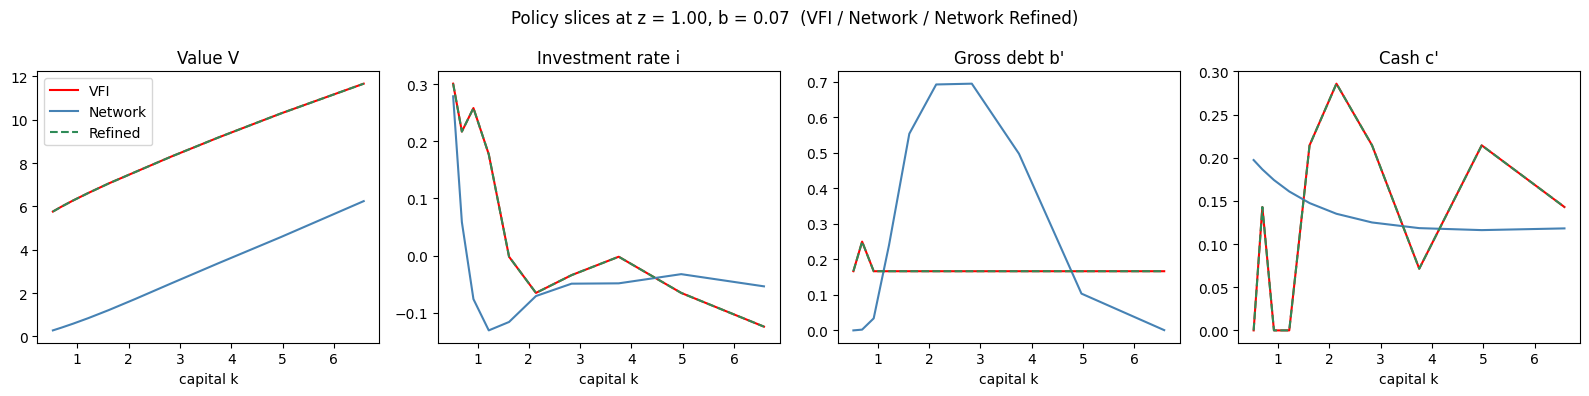

In [6]:
# Figure V3 (Sec 12.3): policy slices vs capital, overlaying VFI / Network / Refined.
slices = policy_slices.k_slices(vfi_sol, net_grid, refined, b_value=-0.03)
fig = figures.plot_k_slices(slices)
artifacts.save_figure(RUN, fig, "fig_v3_policy_slices.png")

dev = policy_slices.deviation_report(vfi_sol, refined, net_grid)
artifacts.save_summary(RUN, dev, "deviation_report.csv")
value_max_rel = next(r["refined_max_rel"] for r in dev if r["quantity"] == "V")
print(f"refined VALUE max-rel vs VFI = {value_max_rel:.4f}  (Sec 12.3 gate: < 0.01)")
print("(per-policy max-rel are bounded by control-grid spacing; they shrink toward BASE resolution)")
pd.DataFrame(dev)

## 5. Property checks + checkpoint

In [7]:
# Economic property checks on the refined solution (Sec 12.4, Groups 1-2).
checks = properties.check_properties(refined, GRID)
artifacts.save_manifest(
    RUN, profile=PROFILE,
    vfi=dict(converged=bool(vfi_sol.converged), sweeps=int(vfi_sol.n_sweeps)),
    final_residual_loss=float(history[-1]["loss_v"]),
    value_max_rel_vs_vfi=float(value_max_rel),
    property_checks=checks,
    deviation_report=dev,
)
ckpt = checkpoints.save_bundle(bundle, str(RUN["run_dir"] / "bundle_ckpt"))
print("property checks:", checks)
print("checkpoint:", ckpt)

property checks: {'bp_in_box': True, 'cp_in_box': True, 'net_debt_in_box': True, 'kp_in_box': True, 'value_finite': True, 'value_nonnegative': True, 'V_increasing_in_z': True, 'V_decreasing_in_b': True}
checkpoint: outputs/v3/block1_vs_vfi/MEDIUM/bundle_ckpt
